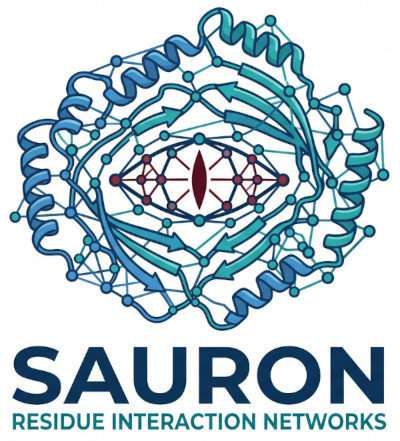
# **Sauron - Residue Interaction Networks**
(Google Colab Version)

This notebook calculates Residue Interaction Networks (RINs) directly in Google Colab. Run the cells sequentially.

The documentation is available in [GitHub](https://github.com/jpmslima/sauron).

Developed by [EvoMol-Lab/BioMe/UFRN](https://evomol-lab.imd.ufrn.br)

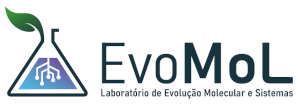

# **1. Install required dependencies:**

In [ ]:
# 1. Install required dependencies
!pip install biopython pandas networkx pydssp pdb2pqr numpy

# **2. Prepare the system and defining functions:**

In [ ]:
import sys
import os
import argparse
import subprocess
import numpy as np
import pandas as pd
import networkx as nx
from Bio.PDB import PDBParser, MMCIFParser, NeighborSearch, Selection

# VDW Radii based on generic values
VDW_RADII = {
    'C': 1.70, 'N': 1.55, 'O': 1.52, 'S': 1.80, 'H': 1.20, 'P': 1.80
}

MC_ATOMS = {'N', 'CA', 'C', 'O', 'OXT'}

def get_vdw_radius(atom_name):
    element = atom_name[0]
    return VDW_RADII.get(element, 1.70)

def format_node_id(res):
    ins = res.id[2]
    if ins == ' ': ins = '_'
    return f"{res.parent.id}:{res.id[1]}:{ins}:{res.resname}"

def get_contact_type(a1, a2):
    t1 = 'LIG' if a1.parent.id[0].startswith('H') else ('MC' if a1.name in MC_ATOMS else 'SC')
    t2 = 'LIG' if a2.parent.id[0].startswith('H') else ('MC' if a2.name in MC_ATOMS else 'SC')
    return f"{t1}_{t2}"

def get_centroid(res):
    if res.resname in ['PHE', 'TYR']:
        atoms = ['CG', 'CD1', 'CD2', 'CE1', 'CE2', 'CZ']
    elif res.resname == 'TRP':
        atoms = ['CG', 'CD1', 'CD2', 'NE1', 'CE2', 'CE3', 'CZ2', 'CZ3', 'CH2']
    elif res.resname == 'HIS':
        atoms = ['CG', 'ND1', 'CD2', 'CE1', 'NE2']
    else:
        return None
    coords = [res[a].coord for a in atoms if a in res]
    if not coords: return None
    return np.mean(coords, axis=0)

def calc_angle(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2
    cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle)

def get_attached_hydrogens(atom):
    hydrogens = []
    for a in atom.parent:
        if a.name.startswith('H') or (len(a.name) > 1 and a.name[0].isdigit() and a.name[1] == 'H'):
            dist = np.linalg.norm(a.coord - atom.coord)
            if dist < 1.3:
                hydrogens.append(a)
    return hydrogens

def check_hbond_angle(a1, a2):
    # Check if a1 is donor
    h1 = get_attached_hydrogens(a1)
    for h in h1:
        angle = calc_angle(a1.coord, h.coord, a2.coord)
        if angle > 120: return True, angle

    # Check if a2 is donor
    h2 = get_attached_hydrogens(a2)
    for h in h2:
        angle = calc_angle(a2.coord, h.coord, a1.coord)
        if angle > 120: return True, angle

    return False, np.nan

def add_hydrogens(input_file):
    output_file = input_file + ".pqr"

    print(f"Adding hydrogens using pdb2pqr to {input_file}...")
    try:
        cmd = ["pdb2pqr", "--ff=PARSE", "--keep-chain", input_file, output_file]

        subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        return output_file
    except Exception as e:
        print(f"pdb2pqr failed or not available: {e}. Falling back to original file.")
        return input_file

def parse_structure(filepath):
    if filepath.endswith('.cif'):
        parser = MMCIFParser(QUIET=True)
    else:
        parser = PDBParser(QUIET=True)
    return parser.get_structure('struct', filepath)

def calculate_rin(structure, strict_angle=False, remove_multiples=False, model_num=1):
    edges = []
    nodes = set()

    atoms = list(structure.get_atoms())
    ns = NeighborSearch(atoms)

    # Get pairs within 6.5 A
    pairs = ns.search_all(6.5)

    # Organize pairs by residues
    res_pairs = {}
    for a1, a2 in pairs:
        r1, r2 = a1.parent, a2.parent
        if r1 == r2: continue

        # Skip Water
        if r1.id[0] == 'W' or r2.id[0] == 'W': continue

        # Avoid i to i+1 MC-MC contacts like peptide bonds
        if abs(r1.id[1] - r2.id[1]) <= 1 and r1.parent == r2.parent:
            # allow SC-SC or MC-SC, but exclude N-C bonding
            if a1.name in ['N', 'C', 'CA', 'O'] and a2.name in ['N', 'C', 'CA', 'O']:
                dist = np.linalg.norm(a1.coord - a2.coord)
                if dist < 2.0: continue # Covalent bond

        key = tuple(sorted([r1, r2], key=lambda x: format_node_id(x)))
        if key not in res_pairs:
            res_pairs[key] = []
        res_pairs[key].append((a1, a2))

    for (r1, r2), atom_pairs in res_pairs.items():
        n1 = format_node_id(r1)
        n2 = format_node_id(r2)
        nodes.add(r1)
        nodes.add(r2)

        # Check specific interactions
        # 1. SSBOND
        if r1.resname == 'CYS' and r2.resname == 'CYS':
            if 'SG' in r1 and 'SG' in r2:
                dist = np.linalg.norm(r1['SG'].coord - r2['SG'].coord)
                if dist <= 2.5:
                    edges.append({
                        'NodeId1': n1, 'Interaction': 'SSBOND:SC_SC', 'NodeId2': n2,
                        'Distance': f"{dist:.3f}", 'Angle': 'nan', 'Atom1': 'SG', 'Atom2': 'SG',
                        'Donor': '', 'Positive': '', 'Cation': '', 'Orientation': '', 'Model': model_num
                    })
                    continue

        # 2. IONIC (Salt bridge)
        pos = {'ARG': ['NH1', 'NH2'], 'LYS': ['NZ'], 'HIS': ['ND1', 'NE2']}
        neg = {'ASP': ['OD1', 'OD2'], 'GLU': ['OE1', 'OE2']}

        for ax, ay in atom_pairs:
            if format_node_id(ax.parent) > format_node_id(ay.parent):
                a1, a2 = ay, ax
            else:
                a1, a2 = ax, ay

            if r1.resname in pos and a1.name in pos[r1.resname] and r2.resname in neg and a2.name in neg[r2.resname]:
                dist = np.linalg.norm(a1.coord - a2.coord)
                if dist <= 4.0:
                    edges.append({
                        'NodeId1': n1, 'Interaction': 'IONIC:SC_SC', 'NodeId2': n2,
                        'Distance': f"{dist:.3f}", 'Angle': 'nan', 'Atom1': a1.name, 'Atom2': a2.name,
                        'Donor': '', 'Positive': '', 'Cation': '', 'Orientation': '', 'Model': model_num
                    })
                    break
            elif r2.resname in pos and a2.name in pos[r2.resname] and r1.resname in neg and a1.name in neg[r1.resname]:
                dist = np.linalg.norm(a1.coord - a2.coord)
                if dist <= 4.0:
                    edges.append({
                        'NodeId1': n1, 'Interaction': 'IONIC:SC_SC', 'NodeId2': n2,
                        'Distance': f"{dist:.3f}", 'Angle': 'nan', 'Atom1': a1.name, 'Atom2': a2.name,
                        'Donor': '', 'Positive': '', 'Cation': '', 'Orientation': '', 'Model': model_num
                    })
                    break

        # 3. PIPISTACK
        aromatics = ['PHE', 'TYR', 'TRP', 'HIS']
        if r1.resname in aromatics and r2.resname in aromatics:
            c1 = get_centroid(r1)
            c2 = get_centroid(r2)
            if c1 is not None and c2 is not None:
                dist = np.linalg.norm(c1 - c2)
                if dist <= 6.5:
                    edges.append({
                        'NodeId1': n1, 'Interaction': 'PIPISTACK:SC_SC', 'NodeId2': n2,
                        'Distance': f"{dist:.3f}", 'Angle': 'nan', 'Atom1': '', 'Atom2': '',
                        'Donor': '', 'Positive': '', 'Cation': '', 'Orientation': 'T', 'Model': model_num
                    })

        # 4. PICATION
        if r1.resname in aromatics and r2.resname in pos:
            c1 = get_centroid(r1)
            c2_coords = [r2[a].coord for a in pos[r2.resname] if a in r2]
            if c1 is not None and c2_coords:
                c2_cm = np.mean(c2_coords, axis=0)
                dist = np.linalg.norm(c1 - c2_cm)
                if dist <= 5.0:
                    edges.append({
                        'NodeId1': n1, 'Interaction': 'PICATION:SC_SC', 'NodeId2': n2,
                        'Distance': f"{dist:.3f}", 'Angle': 'nan', 'Atom1': '', 'Atom2': '',
                        'Donor': '', 'Positive': '', 'Cation': '', 'Orientation': '', 'Model': model_num
                    })
        elif r2.resname in aromatics and r1.resname in pos:
            c2 = get_centroid(r2)
            c1_coords = [r1[a].coord for a in pos[r1.resname] if a in r1]
            if c2 is not None and c1_coords:
                c1_cm = np.mean(c1_coords, axis=0)
                dist = np.linalg.norm(c2 - c1_cm)
                if dist <= 5.0:
                    edges.append({
                        'NodeId1': n1, 'Interaction': 'PICATION:SC_SC', 'NodeId2': n2,
                        'Distance': f"{dist:.3f}", 'Angle': 'nan', 'Atom1': '', 'Atom2': '',
                        'Donor': '', 'Positive': '', 'Cation': '', 'Orientation': '', 'Model': model_num
                    })

        # 5. HBOND & VDW
        # Simplify: Donors (N, O, S), Acceptors (N, O, S)
        # Using DA dist < 3.5 for HBOND if no H. DA dist < 3.9 if H present
        donors_acceptors = {'N', 'O', 'S'}
        hbond_found = False
        vdw_found = False
        min_vdw_dist = 999.0
        best_vdw_pair = None

        for ax, ay in atom_pairs:
            if format_node_id(ax.parent) > format_node_id(ay.parent):
                a1, a2 = ay, ax
            else:
                a1, a2 = ax, ay

            dist = np.linalg.norm(a1.coord - a2.coord)
            el1, el2 = a1.name[0], a2.name[0]

            # Check HBOND
            if el1 in donors_acceptors and el2 in donors_acceptors:
                if dist <= 3.5:
                    angle_val = 150.000
                    if strict_angle:
                        valid, computed_angle = check_hbond_angle(a1, a2)
                        if not valid:
                            continue
                        angle_val = computed_angle

                    edges.append({
                        'NodeId1': format_node_id(a1.parent), 'Interaction': f'HBOND:{get_contact_type(a1, a2)}', 'NodeId2': format_node_id(a2.parent),
                        'Distance': f"{dist:.3f}", 'Angle': f"{angle_val:.3f}", 'Atom1': a1.name, 'Atom2': a2.name,
                        'Donor': format_node_id(a1.parent), 'Positive': '', 'Cation': '', 'Orientation': '', 'Model': 1
                    })
                    hbond_found = True

            # Check VDW
            vdw_dist = get_vdw_radius(a1.name) + get_vdw_radius(a2.name) + 0.5
            if dist <= vdw_dist:
                if dist < min_vdw_dist:
                    min_vdw_dist = dist
                    best_vdw_pair = (a1, a2)

        if not hbond_found and best_vdw_pair:
            a1, a2 = best_vdw_pair
            edges.append({
                'NodeId1': format_node_id(a1.parent), 'Interaction': f'VDW:{get_contact_type(a1, a2)}', 'NodeId2': format_node_id(a2.parent),
                'Distance': f"{min_vdw_dist:.3f}", 'Angle': 'nan', 'Atom1': a1.name, 'Atom2': a2.name,
                'Donor': '', 'Positive': '', 'Cation': '', 'Orientation': '', 'Model': 1
            })

    # Return edges df
    edges_df = pd.DataFrame(edges)
    # Reorder to match format
    cols = ['NodeId1', 'Interaction', 'NodeId2', 'Distance', 'Angle', 'Atom1', 'Atom2', 'Donor', 'Positive', 'Cation', 'Orientation', 'Model']
    if not edges_df.empty:
        edges_df = edges_df[cols]
        if remove_multiples:
            edges_df['Distance_val'] = edges_df['Distance'].astype(float)
            edges_df = edges_df.sort_values('Distance_val')
            edges_df = edges_df.drop_duplicates(subset=['NodeId1', 'Interaction', 'NodeId2'], keep='first')
            edges_df = edges_df.drop(columns=['Distance_val'])
        else:
            edges_df = edges_df.drop_duplicates()

    return edges_df, nodes

def build_nodes_df(nodes, edges_df, pdbFileName="", structure=None, model_num=1):
    G = nx.Graph()
    if not edges_df.empty:
        for idx, row in edges_df.iterrows():
            G.add_edge(row['NodeId1'], row['NodeId2'])

    dssp_dict = {}
    if structure is not None:
        coords = []
        res_list = []
        for res in structure.get_residues():
            if res.id[0] == 'W': continue
            try:
                n = res['N'].coord
                ca = res['CA'].coord
                c = res['C'].coord
                o = res['O'].coord
                coords.append([n, ca, c, o])
                res_list.append(res)
            except KeyError:
                pass
        if coords:
            try:
                import pydssp
                import numpy as np
                coord_arr = np.array(coords)
                ss = pydssp.assign(coord_arr, out_type='c3')
                for res, s in zip(res_list, ss):
                    dssp_dict[res] = s if s != '-' else 'C'
            except Exception as e:
                print(f"DSSP calculation failed: {e}")

    nodes_data = []
    for r in nodes:
        node_id = format_node_id(r)
        chain = r.parent.id
        pos = r.id[1]
        resname = r.resname
        ca_bfactor = 0.0
        x, y, z = 0.0, 0.0, 0.0
        if 'CA' in r:
            ca_bfactor = r['CA'].bfactor
            x, y, z = r['CA'].coord
        else:
            coords = [a.coord for a in r]
            if coords:
                c = np.mean(coords, axis=0)
                x, y, z = c[0], c[1], c[2]

        deg = G.degree(node_id) if G.has_node(node_id) else 0
        dssp_val = dssp_dict.get(r, ' ')
        node_type = 'LIG' if r.id[0].startswith('H') else 'RES'

        nodes_data.append({
            'NodeId': node_id, 'Chain': chain, 'Position': pos, 'Residue': resname,
            'Type': node_type, 'Dssp': dssp_val, 'Degree': deg, 'Bfactor_CA': f"{ca_bfactor:.3f}",
            'x': f"{x:.3f}", 'y': f"{y:.3f}", 'z': f"{z:.3f}", 'pdbFileName': f"{pdbFileName}#{pos}.{chain}", 'Model': model_num
        })

    df = pd.DataFrame(nodes_data)
    cols = ['NodeId', 'Chain', 'Position', 'Residue', 'Type', 'Dssp', 'Degree', 'Bfactor_CA', 'x', 'y', 'z', 'pdbFileName', 'Model']
    if not df.empty:
        df = df[cols].sort_values(by=['Chain', 'Position'])
    return df

def analyze_network(edges_df, nodes_df, prefix):
    if edges_df.empty:
        print("Empty network, skipping metrics.")
        return

    G = nx.Graph()
    for idx, row in edges_df.iterrows():
        G.add_edge(row['NodeId1'], row['NodeId2'])

    # Degree
    degree_dict = dict(G.degree())
    # Clustering Coefficient
    cc_dict = nx.clustering(G)
    # Betweenness
    bw_dict = nx.betweenness_centrality(G)
    # Eigenvector Centrality
    try:
        ec_dict = nx.eigenvector_centrality(G, max_iter=1000)
    except:
        ec_dict = {n: 0.0 for n in G.nodes()}

    metrics = []
    for node in G.nodes():
        metrics.append({
            'NodeId': node,
            'Degree': degree_dict.get(node, 0),
            'Clustering_Coefficient': cc_dict.get(node, 0.0),
            'Betweenness_Centrality': bw_dict.get(node, 0.0),
            'Eigenvector_Centrality': ec_dict.get(node, 0.0)
        })

    df = pd.DataFrame(metrics)

    # Output full table
    df.to_csv(f"{prefix}_network_metrics.tsv", sep='	', index=False)

    # Top 25 tables
    top_deg = df.nlargest(25, 'Degree').reset_index(drop=True)
    top_cc = df.nlargest(25, 'Clustering_Coefficient').reset_index(drop=True)
    top_bw = df.nlargest(25, 'Betweenness_Centrality').reset_index(drop=True)
    top_ec = df.nlargest(25, 'Eigenvector_Centrality').reset_index(drop=True)

    N = len(top_deg)
    if N > 0:
        merged_top25 = pd.DataFrame({
            'Rank': range(1, N + 1),
            'Degree_NodeId': top_deg['NodeId'],
            'Degree': top_deg['Degree'],
            'Betweenness_NodeId': top_bw['NodeId'],
            'Betweenness': top_bw['Betweenness_Centrality'],
            'Clustering_NodeId': top_cc['NodeId'],
            'Clustering': top_cc['Clustering_Coefficient'],
            'Eigenvector_NodeId': top_ec['NodeId'],
            'Eigenvector': top_ec['Eigenvector_Centrality']
        })
        merged_top25.to_csv(f"{prefix}_top25_metrics.tsv", sep='	', index=False)
        print(f"Network metrics saved to {prefix}_network_metrics.tsv and {prefix}_top25_metrics.tsv")

# **3. Upload your pdb(s) or cif(s) files:**

In [ ]:
# @title 3. Upload da Estrutura (PDB ou CIF)
from google.colab import files
uploaded = files.upload()
if uploaded:
    filename = list(uploaded.keys())[0]
    print(f'Arquivo enviado com sucesso: {filename}')
else:
    print('Nenhum arquivo selecionado.')

In [ ]:
# @title 4. Parâmetros de Cálculo
strict_angle = False # @param {type:"boolean"}
# Enforce strict angle constraints for Hydrogen Bonds (>120 deg)

remove_multiples = False # @param {type:"boolean"}
# Remove multiple interactions of the same type between the same pair

add_hydrogens_flag = False # @param {type:"boolean"}
# Add hydrogens using pdb2pqr (takes longer)

### 4.1. Google Drive Integration (Optional)

Enable the checkbox below if you want to save the results directly to your Google Drive. You'll be prompted to authorize Google Drive access.

In [ ]:
# @title 4.1. Configuração do Google Drive
save_to_drive_flag = False # @param {type:"boolean"}
drive_output_folder = "/content/drive/MyDrive/Sauron_RIN_Results" # @param {type:"string"}

from google.colab import drive
import os

if save_to_drive_flag:
    drive.mount('/content/drive')
    os.makedirs(drive_output_folder, exist_ok=True)
    print(f"Google Drive montado. Resultados serão salvos em: {drive_output_folder}")
else:
    print("Integração com Google Drive desativada.")

In [ ]:
# Run Sauron on the uploaded file
from Bio.PDB import PDBIO, Structure

input_file = filename
base_prefix = os.path.splitext(os.path.basename(input_file))[0]
print(f"Processing {input_file}...")

orig_struct = parse_structure(input_file)
models = list(orig_struct.get_models())
io = PDBIO()

for i, orig_model in enumerate(models):
    model_num = orig_model.id if orig_model.id is not None and orig_model.id >= 0 else i + 1
    prefix = f"{base_prefix}_model_{model_num}" if len(models) > 1 else base_prefix

    temp_pdb = f"{prefix}_temp.pdb"
    temp_struct = Structure.Structure("temp")
    temp_struct.add(orig_model)
    io.set_structure(temp_struct)
    io.save(temp_pdb)

    if add_hydrogens_flag:
        pqr_file = add_hydrogens(temp_pdb)
        try:
            struct_to_calc = list(parse_structure(pqr_file).get_models())[0]
        except:
            struct_to_calc = orig_model

        if pqr_file != temp_pdb:
            for orig_chain in orig_model:
                if orig_chain.id not in struct_to_calc: continue
                chain = struct_to_calc[orig_chain.id]
                for orig_res in list(orig_chain):
                    if orig_res.id[0] != ' ' and orig_res.id[0] != 'W':
                        if orig_res.id not in chain:
                            orig_chain.detach_child(orig_res.id)
                            chain.add(orig_res)
    else:
        struct_to_calc = orig_model
        pqr_file = temp_pdb

    edges_df, nodes = calculate_rin(struct_to_calc, strict_angle=strict_angle, remove_multiples=remove_multiples, model_num=model_num)
    nodes_df = build_nodes_df(nodes, edges_df, os.path.basename(input_file), structure=struct_to_calc, model_num=model_num)

    edges_out = f"{prefix}.edges"
    nodes_out = f"{prefix}.nodes"

    if not edges_df.empty:
        edges_df.to_csv(edges_out, sep='	', index=False)
    if not nodes_df.empty:
        nodes_df.to_csv(nodes_out, sep='	', index=False)

    print(f"Generated {edges_out} and {nodes_out}")
    analyze_network(edges_df, nodes_df, prefix)

    if os.path.exists(temp_pdb): os.remove(temp_pdb)
    if pqr_file != temp_pdb and os.path.exists(pqr_file): os.remove(pqr_file)

### **5. Download the generated results (as a ZIP file):**

In [ ]:
import glob
import zipfile
import os
import shutil
from google.colab import files

# Define the zip filename based on the uploaded file
base_name = os.path.splitext(filename)[0]
zip_filename = f'{base_name}_results.zip'

# 1. Create the ZIP archive
print(f"Creating ZIP archive: {zip_filename}...")
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    # Find all files starting with the base name (outputs from the analysis)
    for f in glob.glob(f'{base_name}*'):
        # Don't include the original uploaded file or the zip itself
        if f != filename and f != zip_filename and os.path.isfile(f):
            print(f'Adding {f} to ZIP')
            zipf.write(f)

# 2. Handle Google Drive Save
if 'save_to_drive_flag' in locals() and save_to_drive_flag:
    try:
        dest_path = os.path.join(drive_output_folder, zip_filename)
        shutil.copy(zip_filename, dest_path)
        print(f"Successfully saved to Google Drive: {dest_path}")
    except Exception as e:
        print(f"Failed to save to Drive: {e}")

# 3. Download the ZIP file
if os.path.exists(zip_filename):
    print(f'Downloading {zip_filename}...')
    files.download(zip_filename)
else:
    print("No output files were found to compress.")